In [3]:
import pandas as pd
df = pd.read_csv("ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
# mean
df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

# median
df.groupby("job_title")["salary_in_usd"].median().sort_values(ascending=False).head(10)

job_title
Data Analytics Lead         405000.0
Financial Data Analyst      275000.0
Head of Data                200000.0
Principal Data Engineer     200000.0
Data Architect              180000.0
Analytics Engineer          179850.0
Principal Data Scientist    173762.0
Director of Data Science    168000.0
Data Specialist             165000.0
Applied Data Scientist      157000.0
Name: salary_in_usd, dtype: float64

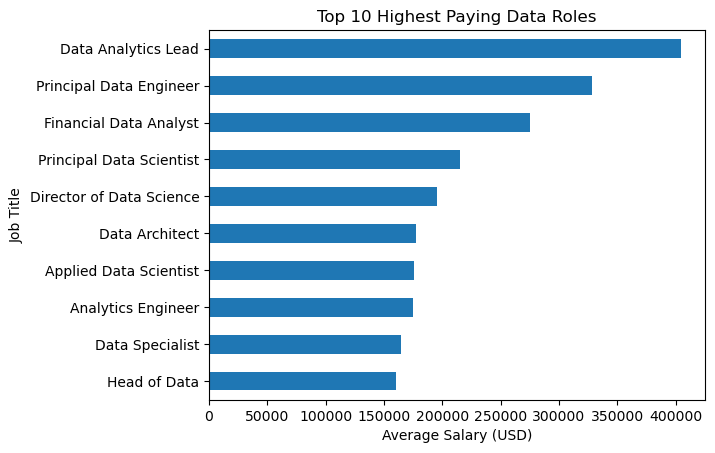

In [6]:
import matplotlib.pyplot as plt

top_roles = df.groupby("job_title")["salary_in_usd"] \
              .mean() \
              .sort_values(ascending=False) \
              .head(10)

top_roles.plot(kind="barh")

plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")
plt.title("Top 10 Highest Paying Data Roles")

plt.gca().invert_yaxis()
plt.show()

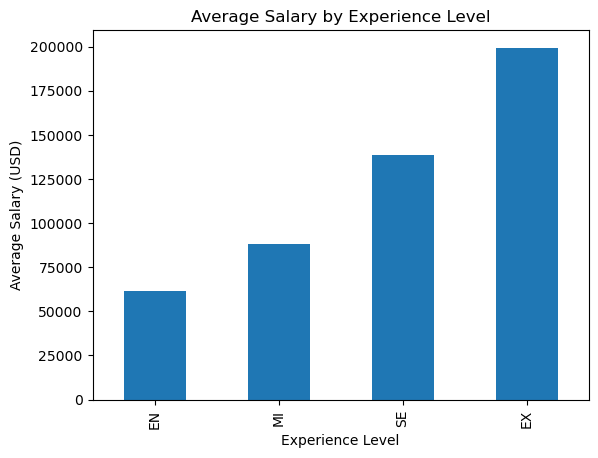

In [7]:
exp_salary = df.groupby("experience_level")["salary_in_usd"].mean().sort_values()

exp_salary.plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.show()

In [8]:
df.groupby("remote_ratio")["salary_in_usd"].mean()

remote_ratio
0      106354.622047
50      80823.030303
100    122457.454068
Name: salary_in_usd, dtype: float64

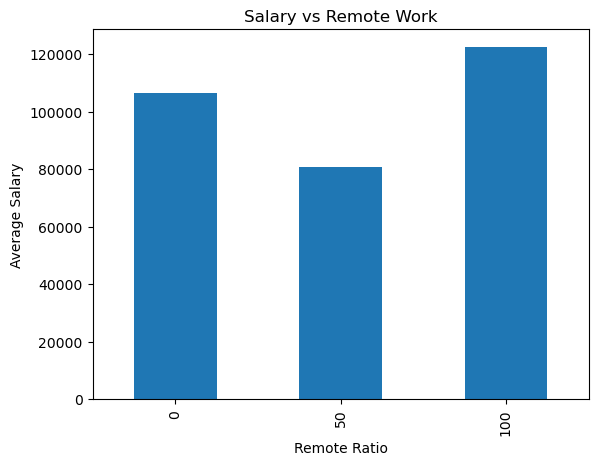

In [9]:
remote_salary = df.groupby("remote_ratio")["salary_in_usd"].mean()

remote_salary.plot(kind="bar")

plt.title("Salary vs Remote Work")
plt.xlabel("Remote Ratio")
plt.ylabel("Average Salary")
plt.show()

In [10]:
df.groupby(["experience_level", "job_title"])["salary_in_usd"].mean().sort_values(ascending=False).head(10)

experience_level  job_title                 
EX                Principal Data Engineer       600000.000000
MI                Financial Data Analyst        450000.000000
EX                Principal Data Scientist      416000.000000
SE                Data Analytics Lead           405000.000000
                  Applied Data Scientist        278500.000000
                  ML Engineer                   256000.000000
EX                Data Engineer                 245500.000000
                  Head of Data                  232500.000000
EN                Machine Learning Scientist    225000.000000
SE                Machine Learning Scientist    201666.666667
Name: salary_in_usd, dtype: float64

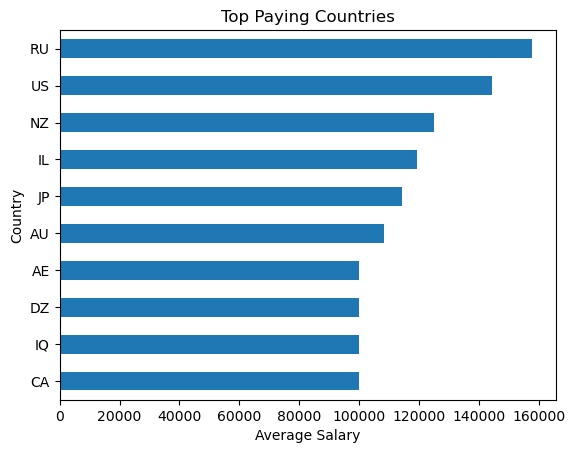

In [11]:
country_salary = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

country_salary.plot(kind="barh")

import matplotlib.pyplot as plt
plt.title("Top Paying Countries")
plt.xlabel("Average Salary")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

In [12]:
pivot = df.pivot_table(
    values="salary_in_usd",
    index="job_title",
    columns="experience_level",
    aggfunc="mean"
)

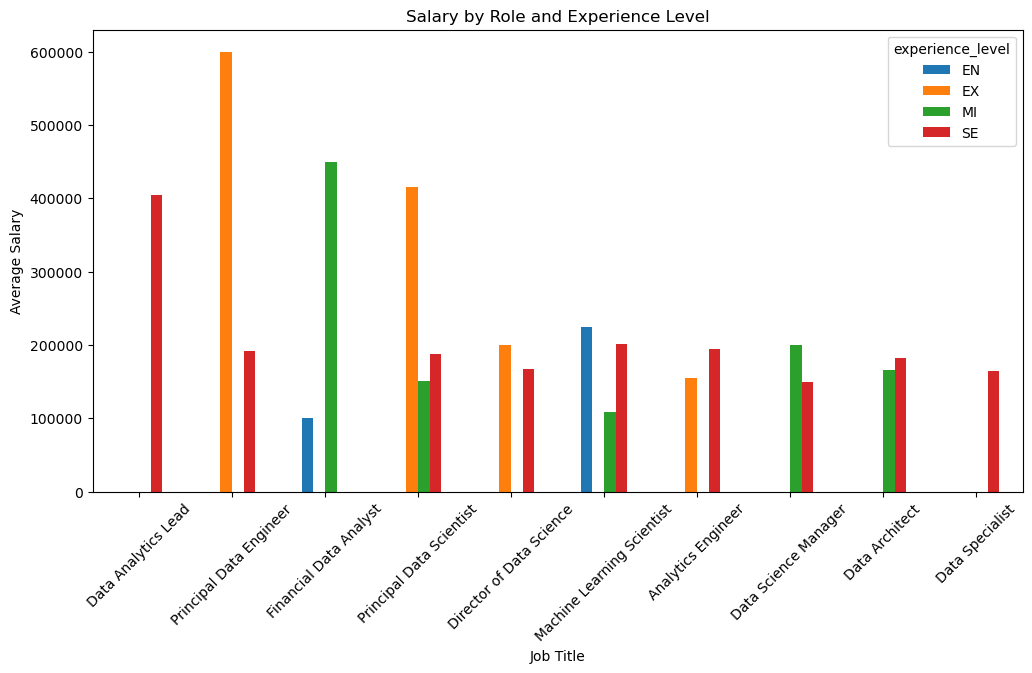

In [13]:
pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).head(10).index] \
     .plot(kind="bar", figsize=(12,6))

import matplotlib.pyplot as plt
plt.title("Salary by Role and Experience Level")
plt.ylabel("Average Salary")
plt.xlabel("Job Title")
plt.xticks(rotation=45)
plt.show()